# Proyecto EDA — Terremotos 2000-2025

In [1]:
#Importamos las librerías necesarias para el análisis y tratamiento de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib as mpl

import sys
import os
sys.path.append(os.path.abspath('../../'))

from src.utils.visualizacion import pinta_distribucion_categoricas, plot_multiple_boxplots, plot_boxplot_grouped
from src.utils.limpieza import tipificar_variables
from src.utils.estadisticos import resumen_estadisticos


## 1. Carga de datos

In [2]:
#Traemos el csv

df_desastres = pd.read_csv('../data/global_natural_disasters_2000_2025.csv')


## 2. Primera exploración

In [3]:
# Primera exploración
df_desastres.head(50)

,disaster_type,date,latitude,longitude,magnitude,depth_km,location,country,deaths,source
0,Earthquake,2000-01-01,36.874,69.947,5.1,54.3,"29 km SSE of Rust?q, Afghanistan",NaN,NaN,USGS
1,Earthquake,2000-01-01,-60.722,153.670,6.0,10.0,west of Macquarie Island,NaN,NaN,USGS
2,Earthquake,2000-01-01,23.112,143.644,5.2,33.0,"Volcano Islands, Japan region",NaN,NaN,USGS
3,Earthquake,2000-01-02,27.559,92.498,5.0,33.0,"33 km NNE of Bomdila, India",NaN,NaN,USGS
4,Earthquake,2000-01-02,-17.943,-178.476,5.5,582.3,"234 km E of Levuka, Fiji",NaN,NaN,USGS
5,Earthquake,2000-01-02,51.447,-175.558,5.8,33.0,"88 km ESE of Adak, Alaska",NaN,NaN,USGS
6,Earthquake,2000-01-02,-20.771,-174.236,5.8,33.0,"95 km ENE of Kolonga, Tonga",NaN,NaN,USGS
7,Earthquake,2000-01-02,51.499,-175.520,5.2,33.0,"87 km ESE of Adak, Alaska",NaN,NaN,USGS
8,Earthquake,2000-01-03,9.634,126.280,5.2,67.9,"23 km SE of Union, Philippines",NaN,NaN,USGS
9,Earthquake,2000-01-04,-20.716,-177.613,5.4,336.4,"254 km WNW of Haveluloto, Tonga",NaN,NaN,USGS


In [4]:
df_desastres.info()

<class 'pandas.DataFrame'>
RangeIndex: 46419 entries, 0 to 46418
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   disaster_type  46419 non-null  str    
 1   date           46419 non-null  str    
 2   latitude       46419 non-null  float64
 3   longitude      46419 non-null  float64
 4   magnitude      46419 non-null  float64
 5   depth_km       46419 non-null  float64
 6   location       46419 non-null  str    
 7   country        0 non-null      float64
 8   deaths         0 non-null      float64
 9   source         46419 non-null  str    
dtypes: float64(6), str(4)
memory usage: 5.9 MB


In [5]:
df_desastres.source.unique()

<ArrowStringArray>
['USGS']
Length: 1, dtype: str

In [6]:
df_desastres.disaster_type.value_counts()

disaster_type
Earthquake    46419
Name: count, dtype: int64

In [7]:
df_desastres.location.unique()

<ArrowStringArray>
[      '29 km SSE of Rust?q, Afghanistan',
               'west of Macquarie Island',
          'Volcano Islands, Japan region',
            '33 km NNE of Bomdila, India',
               '234 km E of Levuka, Fiji',
              '88 km ESE of Adak, Alaska',
            '95 km ENE of Kolonga, Tonga',
              '87 km ESE of Adak, Alaska',
         '23 km SE of Union, Philippines',
        '254 km WNW of Haveluloto, Tonga',
 ...
   '129 km ESE of Alo, Wallis and Futuna',
        '193 km S of Bengkulu, Indonesia',
        '191 km S of Bengkulu, Indonesia',
  '220 km ESE of Severo-Kuril’sk, Russia',
         '37 km NW of Añatuya, Argentina',
             '29 km ESE of Yilan, Taiwan',
          '43 km W of Puerto Santa, Peru',
             '97 km N of Yakutat, Alaska',
 '87 km SSW of Panguna, Papua New Guinea',
           '19 km NNE of Wadomari, Japan']
Length: 28861, dtype: str

In [8]:
df_desastres["date"] = pd.to_datetime(df_desastres["date"])

## 3. Limpieza de datos

In [9]:
#Eliminamos columnas con nulos y otras que no nos interesan:
# - country y deaths: 100% de valores nulos, no aporten información
# - location: muy dispersa y no es el centro del análisis
# - source: no tiene interés analítico
# - disaster_type: el dataset solo contiene terremotos

df_desastres.drop(
    columns=['deaths', 'country', 'location', 'source', 'disaster_type'],
    inplace=True
)

In [10]:
df_desastres

,date,latitude,longitude,magnitude,depth_km
0,2000-01-01,36.8740,69.9470,5.1,54.300
1,2000-01-01,-60.7220,153.6700,6.0,10.000
2,2000-01-01,23.1120,143.6440,5.2,33.000
3,2000-01-02,27.5590,92.4980,5.0,33.000
4,2000-01-02,-17.9430,-178.4760,5.5,582.300
...,...,...,...,...,...
46414,2025-12-30,60.4206,-139.5600,5.1,5.000
46415,2025-12-30,-7.0521,155.1950,5.1,10.000
46416,2025-12-30,-42.7194,83.6078,5.1,10.000
46417,2025-12-30,27.5490,128.7241,5.5,11.000


In [11]:
#Renombramos columnas para mayor claridad
df_desastres.rename(columns={
    "date":      "Date",
    "latitude":  "Latitude",
    "longitude": "Longitude",
    "magnitude": "Richter Magnitude",
    "depth_km":  "Depth (km)"
}, inplace=True)

## 4. Tipificación de variables

In [12]:
#Tipificación de variables usando la función auxiliar de src/utils/limpieza.py
df_tipificacion = tipificar_variables(df_desastres)
df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
Date,9259,19.946574,datetime64[us],Numerica Discreta
Latitude,42097,90.689157,float64,Numerica Continua
Longitude,43108,92.867145,float64,Numerica Continua
Richter Magnitude,103,0.221892,float64,Numerica Discreta
Depth (km),9929,21.389948,float64,Numerica Discreta


In [13]:
#(La clasificación ya la realiza tipificar_variables internamente)

## 5. Estadísticos descriptivos


In [14]:
#Estadísticos descriptivos usando la función auxiliar de src/utils/estadisticos.py
columnas_numericas = ['Richter Magnitude', 'Depth (km)']
resumen_estadisticos(df_desastres, columnas_numericas)

,Richter Magnitude,Depth (km)
Registros,46419.000,46419.000
Media,5.346,54.923
Mediana,5.200,23.580
Desv. Típica,0.410,101.732
Mínimo,5.000,-1.770
<lambda>,5.100,10.000
<lambda>,5.500,46.200
Máximo,9.100,691.600


In [15]:
#Resumen rápido también con describe() para referencia
df_desastres[columnas_numericas].describe().round(3)

,Richter Magnitude,Depth (km)
count,46419.000,46419.000
mean,5.346,54.923
std,0.410,101.732
min,5.000,-1.770
25%,5.100,10.000
50%,5.200,23.580
75%,5.500,46.200
max,9.100,691.600


## 6. Funciones auxiliares de visualización

Importadas desde `src/utils/visualizacion.py`

In [16]:
#pinta_distribucion_categoricas → importada desde src/utils/visualizacion.py

In [17]:
#plot_multiple_boxplots y plot_boxplot_grouped → importadas desde src/utils/visualizacion.py

## 7. Análisis univariante

### 7.1 Profundidad

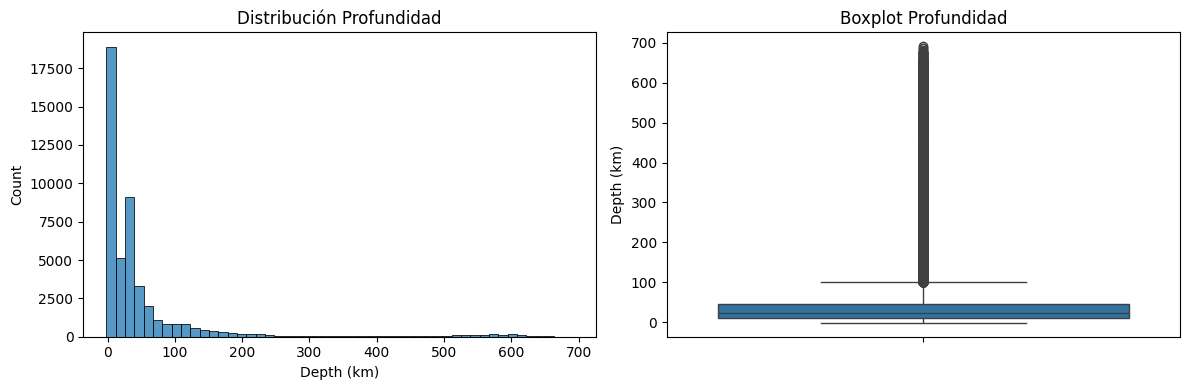

In [18]:
#Profundidad
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_desastres['Depth (km)'], bins=50, ax=axes[0])
axes[0].set_title('Distribución Profundidad')

sns.boxplot(df_desastres['Depth (km)'], ax=axes[1])
axes[1].set_title('Boxplot Profundidad')

plt.tight_layout()
plt.show()

### 7.2 Magnitud Richter

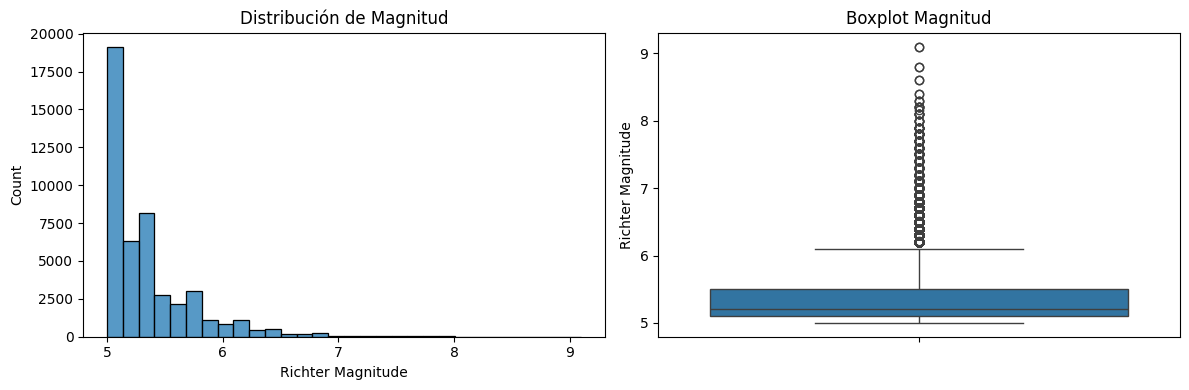

In [19]:
#Magnitud en escala Richter
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_desastres['Richter Magnitude'], bins=30, ax=axes[0])
axes[0].set_title('Distribución de Magnitud')

sns.boxplot(df_desastres['Richter Magnitude'], ax=axes[1])
axes[1].set_title('Boxplot Magnitud')

plt.tight_layout()
plt.show()

### 7.3 Frecuencia temporal anual

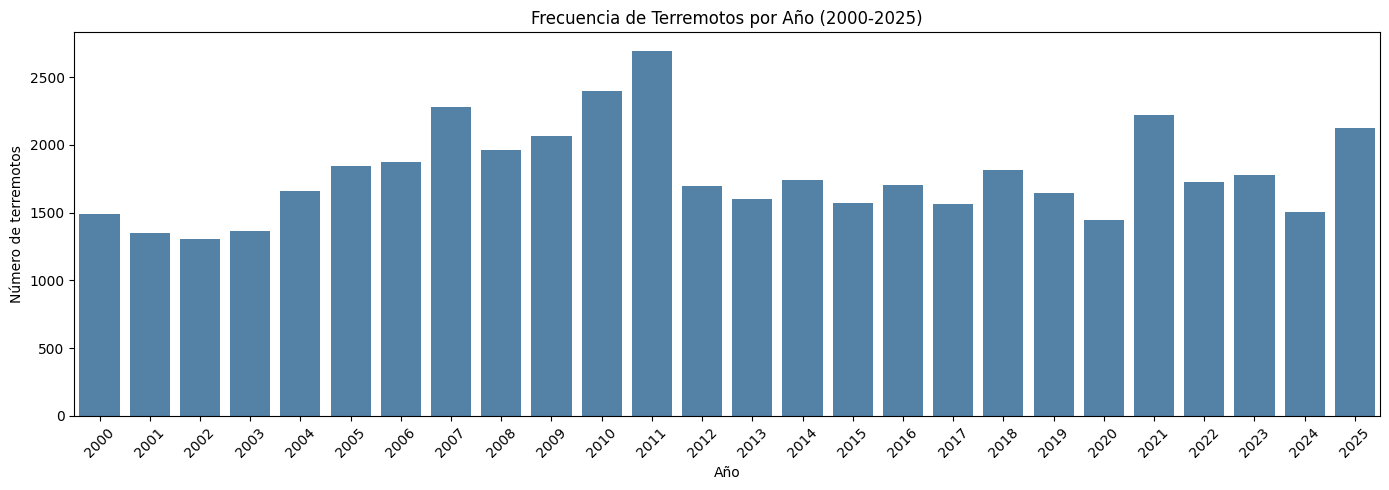

In [20]:
#Frecuencia temporal anual
df_desastres['year'] = df_desastres['Date'].dt.year

terremotos_año = df_desastres.groupby('year').size()

plt.figure(figsize=(14, 5))
sns.barplot(x=terremotos_año.index, y=terremotos_año.values, color='steelblue')
plt.title('Frecuencia de Terremotos por Año (2000-2025)')
plt.xlabel('Año')
plt.ylabel('Número de terremotos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.4 Distribución geográfica

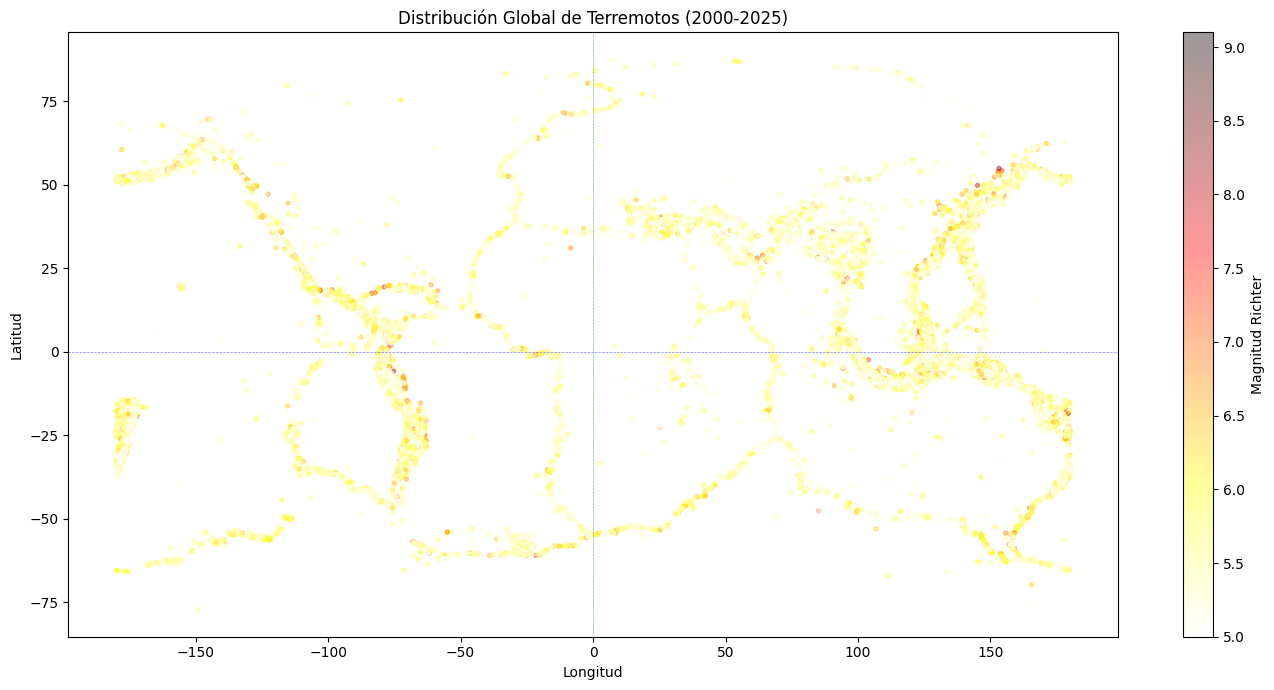

In [21]:
#Distribución geográfica: latitud y longitud
plt.figure(figsize=(14, 7))
scatter = plt.scatter(
    df_desastres['Longitude'],
    df_desastres['Latitude'],
    c=df_desastres['Richter Magnitude'],
    cmap='hot_r',
    alpha=0.4,
    s=8
)
plt.colorbar(scatter, label='Magnitud Richter')
plt.title('Distribución Global de Terremotos (2000-2025)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.axhline(y=0, color='blue', linewidth=0.5, linestyle='--', alpha=0.5)
plt.axvline(x=0, color='green', linewidth=0.5, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()